### 1. 라이브러리

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

### 2.데이터 불러오기

In [4]:
distribution_centers = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/distribution_centers_EDA.csv")
events = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/events_EDA.csv")
inventory_items = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv")
orders = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv")
order_items = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/order_items_EDA.csv")
products = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/products_EDA.csv")
users = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/users_EDA.csv")

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8348\2602760807.py:7: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/users_EDA.csv")


### 3. 판매량·반품 데이터 병합

In [6]:
# 주문 + 주문 아이템 결합
orders_items_merged = pd.merge(order_items, orders, on=["order_id", "user_id"], how="left")

### 4. 회전율(판매 속도) 계산

In [8]:
# 4-1. product_id별 판매 개수
sales_per_product = orders_items_merged.groupby("product_id").size().reset_index(name="sales_count")

# 4-2. inventory_items 'created_at' datetime 변환 및 tz 제거
inventory_items['created_at'] = pd.to_datetime(inventory_items['created_at'], errors='coerce')
inventory_items['created_at'] = inventory_items['created_at'].dt.tz_localize(None)

# 4-3. 제품별 최초 판매일 계산
sales_dates = inventory_items.groupby("product_id")['created_at'].min().reset_index(name="first_date")

# 4-4. 오늘 날짜 (tz-naive)
today = pd.to_datetime("today")

# 4-5. days_active 계산 (최초 판매일 ~ 오늘)
sales_dates['days_active'] = (today - sales_dates['first_date']).dt.days
sales_dates.loc[sales_dates['days_active'] <= 0, 'days_active'] = 1  # 0 이하 방지

# 4-6. 판매량 + 최초 판매일 병합 → 회전율 계산
product_stats = pd.merge(sales_per_product, sales_dates, on="product_id", how="left")
product_stats['turnover_rate'] = product_stats['sales_count'] / product_stats['days_active']


### 5. 반품률 계산

In [10]:
returns_per_product = orders_items_merged.groupby("product_id")['is_returned'].mean().reset_index(name="return_rate")

### 6. 제품 기본 정보 병합

In [12]:
product_info = products[['id', 'category', 'brand', 'retail_price', 'department']]
product_info.rename(columns={'id': 'product_id'}, inplace=True)

df = product_stats.merge(returns_per_product, on="product_id", how="left")
df = df.merge(product_info, on="product_id", how="left")

# 결측치 처리
df['return_rate'] = df['return_rate'].fillna(0)
df['turnover_rate'] = df['turnover_rate'].fillna(0)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8348\1037076831.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_info.rename(columns={'id': 'product_id'}, inplace=True)


### 7. 군집화

In [14]:
X = df[['turnover_rate', 'return_rate']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

###  8. 전략 그룹 라벨링 (회전율·반품률 중앙값 기준)

In [16]:
def map_strategy(row):
    median_turnover = df['turnover_rate'].median()
    median_return = df['return_rate'].median()

    if row['turnover_rate'] > median_turnover and row['return_rate'] <= median_return:
        return "고회전·저반품"
    elif row['turnover_rate'] > median_turnover and row['return_rate'] > median_return:
        return "고회전·고반품"
    elif row['turnover_rate'] <= median_turnover and row['return_rate'] <= median_return:
        return "저회전·저반품"
    else:
        return "저회전·고반품"

In [17]:
df['strategy_group'] = df.apply(map_strategy, axis=1)

### 9. 결과 저장 및 일부 출력

In [19]:
df.to_csv("product_strategy_groups.csv", index=False)

print("전략 그룹 분류 완료: product_strategy_groups.csv 생성")
print(df[['product_id', 'turnover_rate', 'return_rate', 'strategy_group']].head())

전략 그룹 분류 완료: product_strategy_groups.csv 생성
   product_id  turnover_rate  return_rate strategy_group
0           1       0.002364     0.000000        저회전·저반품
1           2       0.002065     0.000000        저회전·저반품
2           3       0.001934     0.000000        저회전·저반품
3           4       0.002654     0.200000        저회전·고반품
4           5       0.004229     0.333333        고회전·고반품


In [20]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import platform

# OS별 한글폰트 설정
if platform.system() == 'Windows':
    font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
elif platform.system() == 'Darwin':  # macOS
    font_path = "/System/Library/Fonts/AppleSDGothicNeo.ttc"
else:
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # 리눅스용, 설치 필요

font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# seaborn 기본 스타일 설정
sns.set(style="whitegrid", palette="pastel", font=font_name, rc={"axes.unicode_minus": False})

print(f"한글 폰트 설정 완료: {font_name}")

한글 폰트 설정 완료: Malgun Gothic


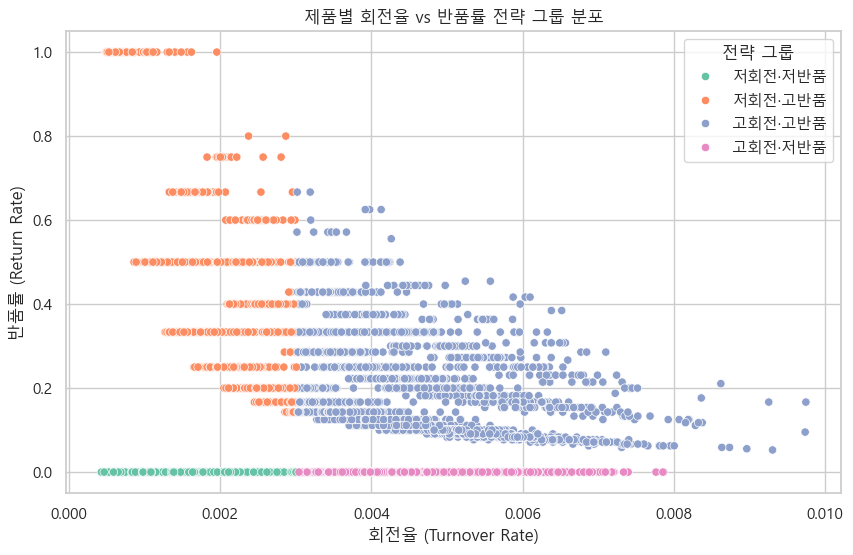

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='turnover_rate', y='return_rate', hue='strategy_group', palette='Set2')
plt.title('제품별 회전율 vs 반품률 전략 그룹 분포')
plt.xlabel('회전율 (Turnover Rate)')
plt.ylabel('반품률 (Return Rate)')
plt.legend(title='전략 그룹')
plt.show()

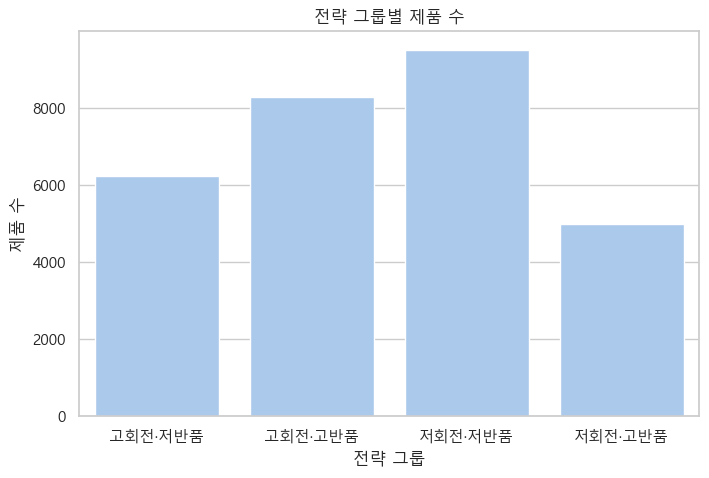

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='strategy_group', order=["고회전·저반품", "고회전·고반품", "저회전·저반품", "저회전·고반품"])
plt.title('전략 그룹별 제품 수')
plt.xlabel('전략 그룹')
plt.ylabel('제품 수')
plt.show()

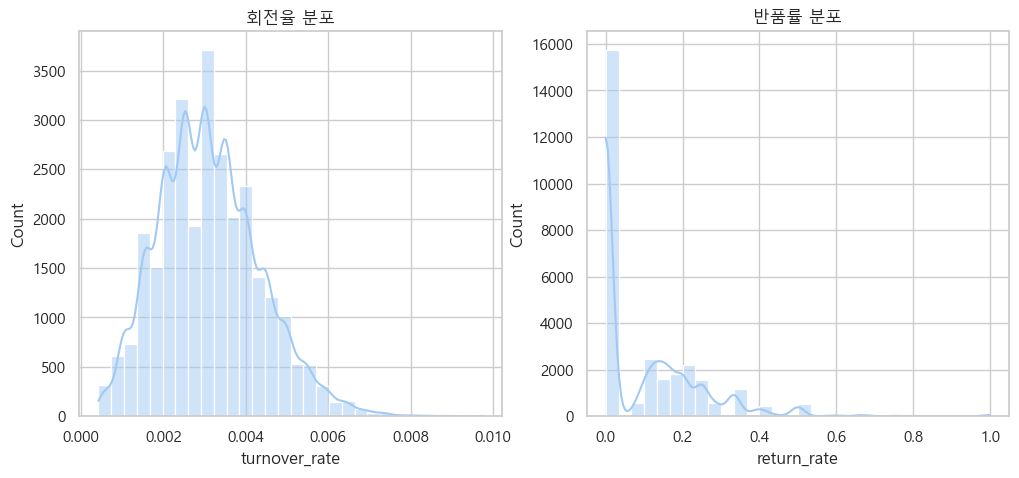

In [39]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['turnover_rate'], bins=30, kde=True)
plt.title('회전율 분포')

plt.subplot(1,2,2)
sns.histplot(df['return_rate'], bins=30, kde=True)
plt.title('반품률 분포')

plt.show()

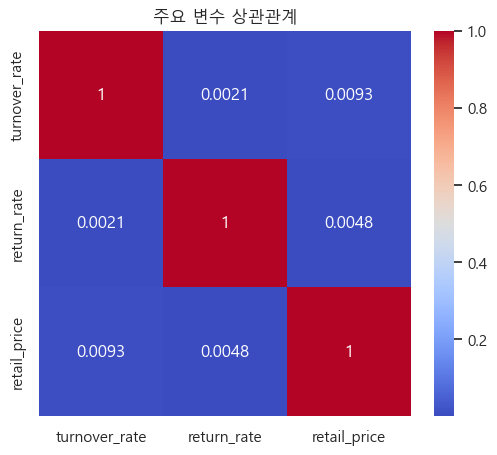

In [41]:
numeric_cols = ['turnover_rate', 'return_rate', 'retail_price']
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('주요 변수 상관관계')
plt.show()

In [63]:
print(product_stats.columns)

Index(['product_id', 'sales_count', 'return_count', 'return_rate'], dtype='object')


In [65]:
# 1. product_stats에 days_active 컬럼이 없다면 먼저 days_active 계산을 해야 함
# inventory_items에 'created_at' 컬럼이 있고, 최초 판매일 기준으로 days_active 계산

sales_dates = inventory_items.groupby("product_id")['created_at'].min().reset_index(name="first_date")
sales_dates['first_date'] = pd.to_datetime(sales_dates['first_date']).dt.tz_localize(None)
sales_dates['days_active'] = (pd.to_datetime("today") - sales_dates['first_date']).dt.days
sales_dates.loc[sales_dates['days_active'] <= 0, 'days_active'] = 1  # 0 이하 방지

# 2. days_active를 product_stats에 병합
product_stats = pd.merge(product_stats, sales_dates[['product_id', 'days_active']], on='product_id', how='left')

# 3. turnover_rate 계산
product_stats['turnover_rate'] = product_stats['sales_count'] / product_stats['days_active']

In [67]:
# (기존에 turnover_rate, return_rate 계산 후)

# 1. 임계값 설정
turnover_threshold = product_stats['turnover_rate'].median()
return_threshold = product_stats['return_rate'].median()

# 2. 전략 분류 함수
def classify_strategy(row):
    if row['turnover_rate'] >= turnover_threshold and row['return_rate'] < return_threshold:
        return '고회전·저반품'
    elif row['turnover_rate'] >= turnover_threshold and row['return_rate'] >= return_threshold:
        return '고회전·고반품'
    elif row['turnover_rate'] < turnover_threshold and row['return_rate'] < return_threshold:
        return '저회전·저반품'
    else:
        return '저회전·고반품'

# 3. 전략 컬럼 생성
product_stats['strategy'] = product_stats.apply(classify_strategy, axis=1)

 전략별 요약 통계
  strategy  turnover_rate  return_rate  sales_count
0  고회전·고반품       0.004618     0.222222        16318
1  고회전·저반품       0.004514     0.076923        52186
2  저회전·고반품       0.002610     0.250000        34886
3  저회전·저반품       0.002588     0.000000        73964


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8348\138090860.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=strategy_counts, x='strategy', y='count', palette='Set2')


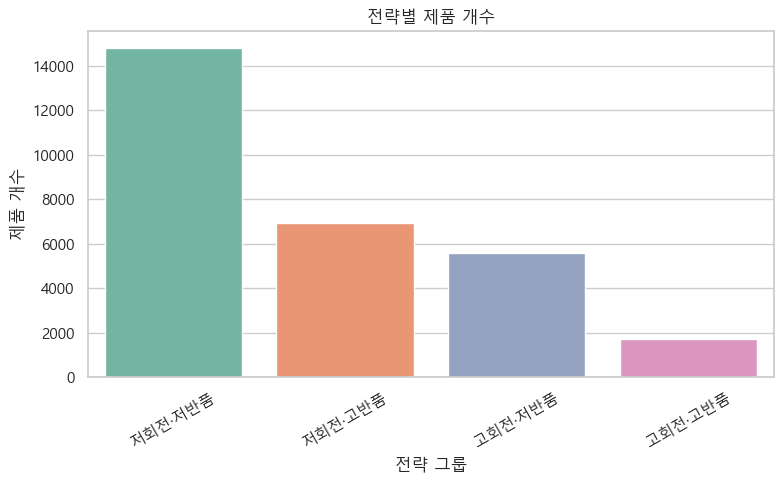

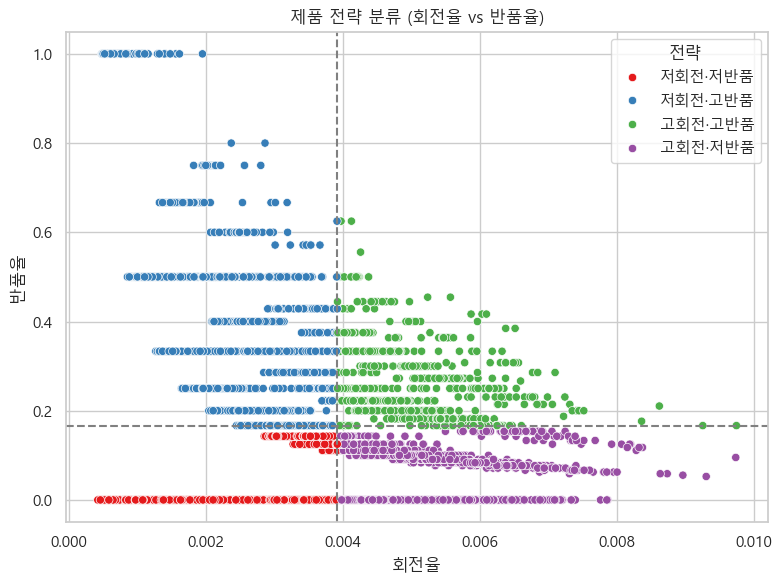

In [75]:
# 1. 임계값을 25%, 75% 분위수로 설정 (좀 더 분포 반영 가능)
turnover_q3 = product_stats['turnover_rate'].quantile(0.75)
return_q3 = product_stats['return_rate'].quantile(0.75)

# 2. 전략 분류 함수 (4가지 그룹)
def classify_strategy(row):
    if row['turnover_rate'] >= turnover_q3:
        if row['return_rate'] >= return_q3:
            return '고회전·고반품'
        else:
            return '고회전·저반품'
    else:
        if row['return_rate'] >= return_q3:
            return '저회전·고반품'
        else:
            return '저회전·저반품'

# 3. 전략 컬럼 생성
product_stats['strategy'] = product_stats.apply(classify_strategy, axis=1)

# 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 전략별 제품 수
strategy_counts = product_stats['strategy'].value_counts().reset_index()
strategy_counts.columns = ['strategy', 'count']

# 전략별 요약 통계
strategy_summary = product_stats.groupby('strategy').agg({
    'turnover_rate': 'median',
    'return_rate': 'median',
    'sales_count': 'sum'
}).reset_index()

print(" 전략별 요약 통계")
print(strategy_summary)

# 막대그래프: 전략별 제품 수
plt.figure(figsize=(8,5))
sns.barplot(data=strategy_counts, x='strategy', y='count', palette='Set2')
plt.title("전략별 제품 개수")
plt.xlabel("전략 그룹")
plt.ylabel("제품 개수")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 산점도: 회전율 vs 반품율
plt.figure(figsize=(8,6))
sns.scatterplot(data=product_stats, x='turnover_rate', y='return_rate', hue='strategy', palette='Set1')
plt.axvline(turnover_q3, color='gray', linestyle='--')
plt.axhline(return_q3, color='gray', linestyle='--')
plt.title("제품 전략 분류 (회전율 vs 반품율)")
plt.xlabel("회전율")
plt.ylabel("반품율")
plt.legend(title='전략')
plt.tight_layout()
plt.show()

In [71]:
# 1. strategy 컬럼 값 분포 확인 (빈도 확인)
print(product_stats['strategy'].value_counts(dropna=False))

# 2. 회전율, 반품율 통계 확인
print(product_stats[['turnover_rate', 'return_rate']].describe())

# 3. 이상치나 극단값 확인 (특히 0 또는 NaN 값)
print(product_stats[product_stats['turnover_rate'] <= 0])
print(product_stats[product_stats['return_rate'] <= 0])


strategy
고회전·고반품    14517
저회전·고반품    14516
Name: count, dtype: int64
       turnover_rate   return_rate
count   29033.000000  29033.000000
mean        0.003114      0.100086
std         0.001225      0.136706
min         0.000427      0.000000
25%         0.002203      0.000000
50%         0.003008      0.000000
75%         0.003923      0.166667
max         0.009746      1.000000
Empty DataFrame
Columns: [product_id, sales_count, return_count, return_rate, days_active, turnover_rate, strategy]
Index: []
       product_id  sales_count  return_count  return_rate  days_active  \
0               1            4             0          0.0         1692   
1               2            4             0          0.0         1937   
2               3            4             0          0.0         2068   
5               6            4             0          0.0         1889   
9              10            3             0          0.0         1665   
...           ...          ...           ...  

In [73]:
print(product_stats['strategy'].value_counts())

strategy
고회전·고반품    14517
저회전·고반품    14516
Name: count, dtype: int64
